In [1]:
import sys

sys.path.append("../..")
# imports
from datetime import date, timedelta
import itertools
import json
from matplotlib import pyplot as plt
import numpy as np
import polars as pl
from sklearn.metrics import classification_report, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
import time

from analysis.datasets.stocks import load_dataset, append_future_returns
from analysis.db.queries import run_custom_query
from analysis.return_classification.decision_tree import DecisionTreeConfig, search_hyperparameters
from etl.transformation.silver import GoodSymbolsSilver
from etl.transformation.gold import StocksDailyGold


DATAPLATFORM_ROOT = "../../dataplatform"

In [37]:
FEATURE_LIST = [
    "log_return_1d",
    "log_return_1w",
    "log_return_1m",
    "log_return_30_steps",
    "return_1d",
    "return_1w",
    "return_1m",
    "return_30_steps",
    "open",
    "open_rolling_1_steps_1d",
    "open_rolling_1w",
    "open_rolling_1m",
    "open_rolling_6m",
    "open_rolling_1y",
    # "volatility_1_steps_1d",
    "volatility_1w",
    "volatility_1m",
    "volatility_1y",
    # "sharpe_1_steps_1d",
    "sharpe_1w",
    "sharpe_1m",
    "rsi",
    "rsi_1d",
    "rsi_1w",
    "shares_outstanding",
    "estimated_float_shares",
    "earnings",
    "evaluation",
    "price_to_earnings",
    "float_adjusted_market_cap",
    "earnings_per_share",
]

# lf = load_dataset(FEATURE_LIST, date(2020, 1, 1), date(2025, 1, 1), dataplatform_root=DATAPLATFORM_ROOT)
lf = StocksDailyGold(dataplatform_root=DATAPLATFORM_ROOT)\
        .read_from_disk()\
        .filter(pl.col("timeframe") >= date(2005, 1, 1), pl.col("timeframe") <= date(2025, 1, 1))\
        .select("symbol", "timeframe", *FEATURE_LIST)\
        .sort("timeframe")
good_symbols = GoodSymbolsSilver(dataplatform_root=DATAPLATFORM_ROOT).read_from_disk()
lf = lf.join(good_symbols, on=["timeframe", "symbol"], how="inner")

lf = append_future_returns(lf, lookahead_steps=5, thresholds=[0.01, 0.03])
lf = lf.drop("future_price")
df = lf.collect()
print(f"Loaded {df.height} rows")

[16:01:31] Loading from disk data model stocks_daily
[16:01:31] gold/stocks_daily scan plan ready from disk
[16:01:31] Loading from disk data model good_symbols
[16:01:31] silver/good_symbols scan plan ready from disk
Loaded 6917397 rows


In [38]:
# drop latest rows for which the label is not available, and turn the
# category-cut enum into a plain numeric label -- keep the category strings
# (e.g. "(0.01, 0.03]") around so downstream plots/reports can show the
# actual return range a label corresponds to, indexed by its numeric code
df = df.drop_nulls(subset="price_movement_class")
LABEL_NAMES = df["price_movement_class"].cat.get_categories().to_list()
df = df.with_columns(
    pl.col("price_movement_class").to_physical().alias("label")
).drop("price_movement_class")

# encode symbols as unique integers
encoder = LabelEncoder()
df = df.with_columns(pl.Series("symbol", encoder.fit_transform(df["symbol"].to_numpy())))

# drop rows with infinite/NaN values, as they conflict with DT training
# ("timeframe" is kept around for the train/test split further down)
float_cols = [c for c, dt in df.schema.items() if dt.is_float()]
df = df.filter(pl.all_horizontal([pl.col(c).is_finite().fill_null(False) for c in float_cols]))

In [39]:
print(f"working with columns ({df.shape[1]}): {df.columns}")
print(f"total samples {df.shape[0]}")
print(f"memory usage of the dataset {df.estimated_size('gb')}GB")
print(f"computed return labels: {df['label'].unique().sort().to_list()}")
print(df.head())

x, y = df.drop("label", "timeframe"), df["label"]

# use the last year of data as a test set
cutoff = df["timeframe"].max() - timedelta(days=365)
train_mask = df["timeframe"] < cutoff

xtrain, xtest = x.filter(train_mask), x.filter(~train_mask)
ytrain, ytest = y.filter(train_mask), y.filter(~train_mask)
print(f"trainset size {xtrain.shape[0]} rows, {xtrain.estimated_size('gb')}GB")


working with columns (32): ['symbol', 'timeframe', 'log_return_1d', 'log_return_1w', 'log_return_1m', 'log_return_30_steps', 'return_1d', 'return_1w', 'return_1m', 'return_30_steps', 'open', 'open_rolling_1_steps_1d', 'open_rolling_1w', 'open_rolling_1m', 'open_rolling_6m', 'open_rolling_1y', 'volatility_1w', 'volatility_1m', 'volatility_1y', 'sharpe_1w', 'sharpe_1m', 'rsi', 'rsi_1d', 'rsi_1w', 'shares_outstanding', 'estimated_float_shares', 'earnings', 'evaluation', 'price_to_earnings', 'float_adjusted_market_cap', 'earnings_per_share', 'label']
total samples 5447298
memory usage of the dataset 1.2949318494647741GB
computed return labels: [0, 1, 2, 3, 4]
shape: (5, 32)
┌────────┬────────────┬────────────┬────────────┬───┬────────────┬────────────┬────────────┬───────┐
│ symbol ┆ timeframe  ┆ log_return ┆ log_return ┆ … ┆ price_to_e ┆ float_adju ┆ earnings_p ┆ label │
│ ---    ┆ ---        ┆ _1d        ┆ _1w        ┆   ┆ arnings    ┆ sted_marke ┆ er_share   ┆ ---   │
│ i64    ┆ date   

# Some data visualization

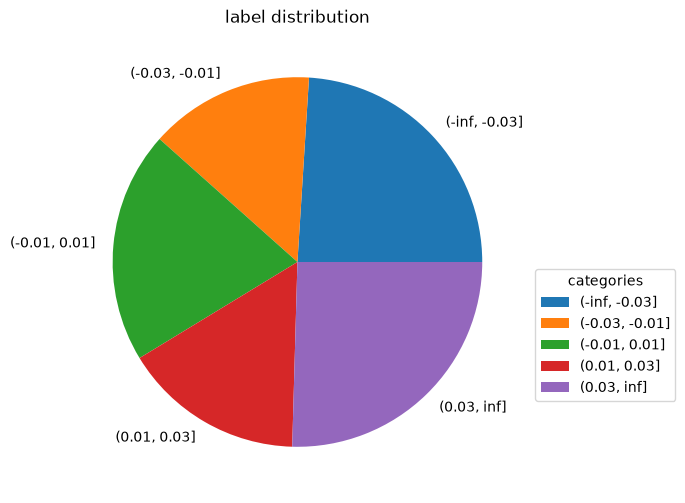

In [40]:
counts = ytrain.value_counts().sort("label")
plt.figure(figsize=(10, 6))
plt.pie(x=counts["count"], labels=[LABEL_NAMES[l] for l in counts["label"]])
plt.title("label distribution")
plt.legend(
    [LABEL_NAMES[l] for l in counts["label"]],
    title="categories",
    bbox_to_anchor=(1, 0.5)
)
plt.show()

# Classifier definitions with relative hyperparameter grids + train

In [ ]:
# hyperparameter grid to search over -- each combination is trained and
# logged as its own mlflow run by `search_hyperparameters`
param_grid = {
    "max_depth": [5, 10, 15, 20],
    "min_samples_split": [2, 10, 20],
    "max_features": [None, "sqrt"],
    "ccp_alpha": [0.0, 0.01, 0.1],
    "class_weight": [None, "balanced"],
}
overrides = [
    dict(zip(param_grid.keys(), values))
    for values in itertools.product(*param_grid.values())
]
print(f"searching {len(overrides)} hyperparameter combinations")

# no separate validation split exists, so the held-out test set doubles as
# the validation set used to rank hyperparameter combinations
results = search_hyperparameters(
    overrides,
    xtrain.to_numpy(),
    ytrain.to_numpy(),
    xtest.to_numpy(),
    ytest.to_numpy(),
    extra_params={"feature_list": FEATURE_LIST},
)

best = results[0]
print(f"best overrides: {best['overrides']}")
print(
    f"val_accuracy={best['result'].val_accuracy} val_f1={best['result'].val_f1}"
)

searching 144 hyperparameter combinations


2026/07/14 16:02:11 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/14 16:02:11 INFO mlflow.store.db.utils: Updating database tables
2026/07/14 16:02:13 INFO mlflow.tracking.fluent: Experiment with name 'return-window-classifier-tree' does not exist. Creating a new experiment.
2026/07/14 16:03:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


train_accuracy=0.3690458015798974 val_accuracy=0.36812575448676 val_f1=0.2754655951547629


2026/07/14 16:03:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/07/14 16:05:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


train_accuracy=0.352019716572283 val_accuracy=0.3537222921750716 val_f1=0.32293534849804445


...

2026/07/14 17:41:35 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/07/14 17:42:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


train_accuracy=0.2545154784129051 val_accuracy=0.24826305631217502 val_f1=0.07955472368000212


2026/07/14 17:42:13 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/07/14 17:46:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


train_accuracy=0.39648550745551797 val_accuracy=0.36703905731382636 val_f1=0.285414297029421


2026/07/14 17:46:08 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


# Search results analysis

In [ ]:
# accuracy/F1 for the best and worst N hyperparameter combinations
N = 5
top = list(enumerate(results[:N], start=1))
bottom = list(enumerate(results[-N:], start=len(results) - N + 1))
selected = top + bottom

accs = [r["result"].val_accuracy for _, r in selected]
f1s = [r["result"].val_f1 for _, r in selected]
xpos = np.arange(len(selected))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar(xpos - width / 2, accs, width, label="val_accuracy")
plt.bar(xpos + width / 2, f1s, width, label="val_f1")
plt.xticks(xpos, [f"#{rank}" for rank, _ in selected], rotation=45, ha="right")
plt.axvline(len(top) - 0.5, color="gray", linestyle="--", linewidth=1)
plt.ylabel("score")
plt.title(f"Top {N} vs bottom {N} hyperparameter combinations (ranked by val_accuracy)")
plt.legend()
plt.tight_layout()
plt.show()

for rank, r in selected:
    print(
        f"#{rank}: {r['overrides']} -> "
        f"val_accuracy={r['result'].val_accuracy:.4f} val_f1={r['result'].val_f1:.4f}"
    )

In [ ]:
# in-depth per-class precision/recall for the best combination
best_model = results[0]["result"].model
y_true = ytest.to_numpy()
y_pred = best_model.predict(xtest.to_numpy())

classes = sorted(np.unique(y_true))
class_names = [LABEL_NAMES[c] for c in classes]
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=classes)

xpos = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(xpos - width, precision, width, label="precision")
plt.bar(xpos, recall, width, label="recall")
plt.bar(xpos + width, f1, width, label="f1")
plt.xticks(xpos, class_names, rotation=20, ha="right")
plt.xlabel("return class")
plt.ylabel("score")
plt.title(f"Per-class precision/recall/F1 -- best combination (#1: {results[0]['overrides']})")
plt.legend()
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, labels=classes, target_names=class_names))